In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)


In [2]:
mnist.DESCR
#这是一个描述函数，描述这个数据集是什么，也可以直接输出这个数据集，输出的全部内容。

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [3]:
X = mnist.data
y = mnist.target
print(X.shape,y,y.shape)

(70000, 784) ['5' '0' '4' ... '4' '5' '6'] (70000,)


In [4]:
X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [5]:
X_train.shape,y_train.shape

((60000, 784), (60000,))

In [6]:
#多标签分类，即把一个目标标记为多个标签，如5即小于7，也是奇数
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
#字符串比大小要慎重，其逻辑和数字不一样！！这里的数组中全是单个数字的字符串，才能比较！
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
knn_clf.predict(X_train[:5])

array([[False,  True],
       [False, False],
       [False, False],
       [False,  True],
       [ True,  True]])

In [8]:
knn_clf.fit(X_train,y_train)
knn_clf.predict(X_test)

array(['7', '2', '1', ..., '4', '5', '6'], shape=(10000,), dtype=object)

In [9]:
knn_clf.score(X_test,y_test)

0.9688

超参数网格搜索
下边fit中可以先用前10000张图片进行，节省时间，但是会减少精确度。但是减少时间会很多！！！


weights (权重策略)：
"uniform"：一人一票。不管邻居离你多远，只要是邻居，投票权重一样。
"distance"：距离越近，权重越大。离你越近的邻居，它的一票越重要。
n_neighbors (邻居数量)：
尝试 k=3，k=4，k=5，k=6。

cv=5，等于五次交叉，

一共是2*4*5=40，40次计算和评估，时间较长，建议前10000

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)
grid_search.fit(X_train[:10000], y_train[:10000])

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [3, 4, ...], 'weights': ['uniform', 'distance']}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [11]:
print(grid_search.best_params_) 
print(grid_search.best_score_)
#最优参数和最好分数，但这是在前10000张图片。

{'n_neighbors': 4, 'weights': 'distance'}
0.9441999999999998


In [12]:
grid_search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = grid_search.score(X_test, y_test)
tuned_accuracy

0.9714

ok,达到97%以上，同时记住这个模型的输出结果是，是否大于等于7，以及是否为奇数。

< >=7,准确率为0.9714
改为大于等于5，其他不变，准确率为0.9714
证明这个为里边的参数关系可能不是很大

要做测试的话，需要输入一行28*28的数据。

以下是编写函数移动，


In [13]:
import matplotlib.pyplot as plt
#画图

In [14]:
from scipy.ndimage import shift

In [15]:
def move_image(image,dx,dy):
    image_reshape = image.reshape((28, 28))  #这一步是将一维的数组重塑为二维的矩阵，记得是两个括号。
    move_image = shift(image_reshape, [dx,dy], cval = 0, mode="constant")  #dx dy 可以换地方，移动方向也会发生变化，但是一画图就知道是往那边了
    return move_image.reshape([-1])

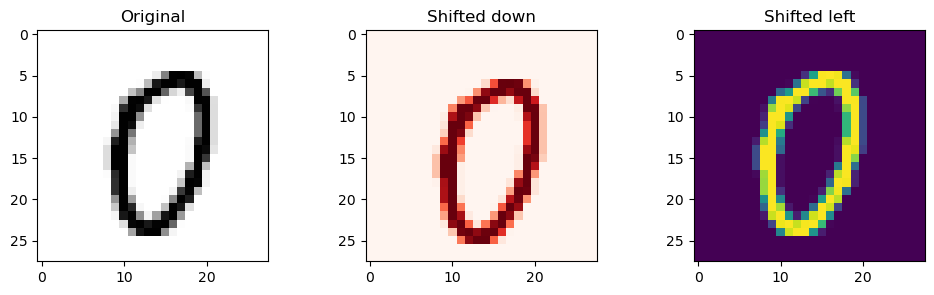

In [16]:
image = X_train[1000]
move_image_down = move_image(image, 1, 0)
move_image_up = move_image(image, -1, 0)
move_image_left = move_image(image, 0, -1)
move_image_right = move_image(image, 0, 1)
#上边是[dx, dy]，这四个函数的名称就是对的，其实也不需要纠结那个是那个，试一下就知道了


plt.figure(figsize=(12, 3))     #画板，宽12，高3
plt.subplot(131)                #小图，1，3，1=一行三列第一列   同理，1，3，2=一行三列第二列 subplot只是分开图片，不是画图，后续的imshow决定图的样式！
plt.title("Original")           #命名 分清楚是哪一张
plt.imshow(image.reshape(28, 28),                    #将图片的数据改为二维的28*28   imshow是展示图片,就是将这些28*28数据展示出来，
           interpolation="nearest", cmap="Greys")     #interpolation="nearest" (插值方式) 不做模糊处理，cmap = color map ,颜色，也可以不定义，就是黄绿色
plt.subplot(132)
plt.title("Shifted down")
plt.imshow(move_image_down.reshape(28, 28),
            interpolation="nearest" ,cmap="Reds")
plt.subplot(133)
plt.title("Shifted left")
plt.imshow(move_image_left.reshape(28, 28),
           interpolation="nearest")
plt.show() #展示

In [18]:
#这是搞了一个for 循环来扩展数据
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):   #zip 的作用：它像拉链一样，把图片 (image) 和它对应的标签 (label) 配对在一起，一次拿出一对。
        X_train_augmented.append(move_image(image, dx, dy))       
        y_train_augmented.append(label)     
#append：把这张新图加入到大列表 X_train_augmented 中。
#关键点：y_train_augmented.append(label)标签不变——因为数字 "5" 往左移一像素，它依然是 "5"。所以我们直接把原始标签复制一份追加进去

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [19]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]
#洗牌，打乱全部的数据，但是X_train_augmented 和 y_train_augmented里边的对应关系不变，也就是打乱的结果是一样的，同步打乱。

In [20]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)
#这一步也可以自己定义参数，上边有了最优的结果，n_neighbors = 4, weight = 'distance',即：
# knn_clf = KNeighborsClassifier(n_neighbors = 4, weight = 'distance')


In [21]:
knn_clf.fit(X_train_augmented, y_train_augmented)
#300000图片，时间较长

,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

0.9763

In [23]:
error_rate_change = (1 - augmented_accuracy) / (1 - tuned_accuracy) - 1
print(f"error_rate_change = {error_rate_change:.0%}")

error_rate_change = -17%
